/Users/antoniaspoerk/Desktop/Digital Neuroscience /Social Media Analytics/epilepsy_pediatrics_EEG/data/graphs/adjacency_sparse
Matrix Shape: [176640 176640]
Non-zero edges: 3956402
Density: 0.000127


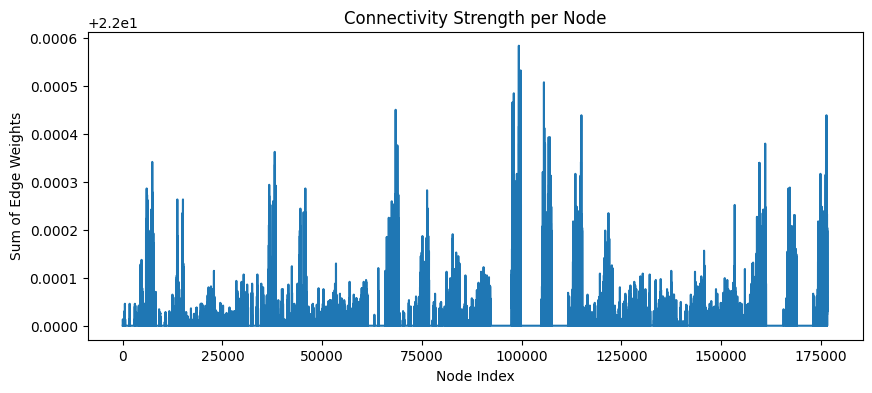

In [10]:
import numpy as np
from pathlib import Path
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt

%cd "/Users/antoniaspoerk/Desktop/Digital Neuroscience /Social Media Analytics/epilepsy_pediatrics_EEG/data/graphs/adjacency_sparse"
RAW_DIR = Path(".") 
container = np.load('inter_to_ict_chb01_03_2980_3010_adjacency_sparse.npz')
data = container['data']
indices = container['indices']
indptr = container['indptr']
shape = container['shape']
adj = csr_matrix((data, indices, indptr), shape=shape)

nnz = adj.nnz  # Number of non-zero edges
density = nnz / (shape[0] * shape[1])
print(f"Matrix Shape: {shape}")
print(f"Non-zero edges: {nnz}")
print(f"Density: {density:.6f}")

row_sums = np.asarray(adj.sum(axis=1)).flatten()
plt.figure(figsize=(10, 4))
plt.plot(row_sums)
plt.title("Connectivity Strength per Node")
plt.xlabel("Node Index")
plt.ylabel("Sum of Edge Weights")
plt.show()

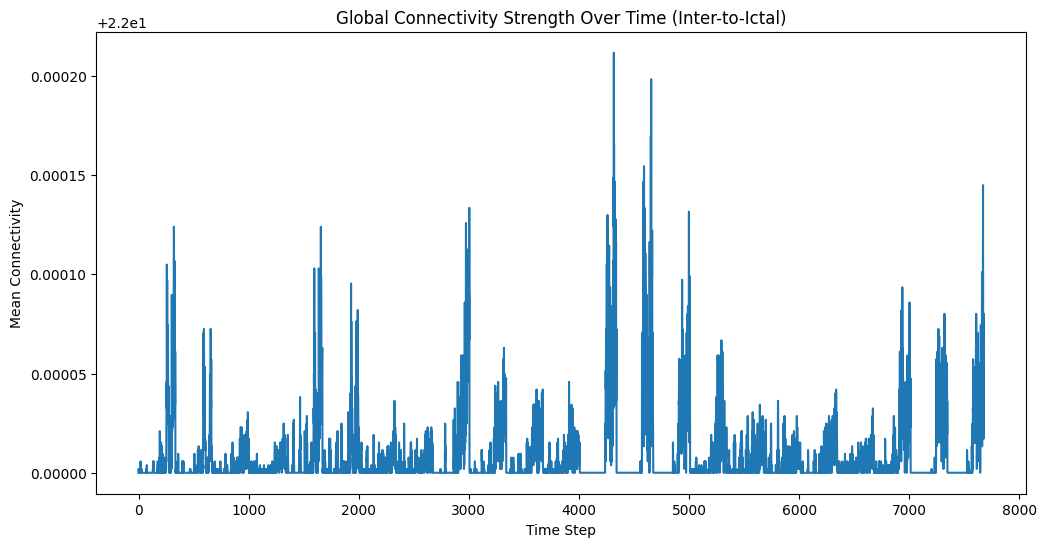

In [16]:
node_strength = np.asarray(adj.sum(axis=1)).flatten()

# If CHB-MIT usually has 23 channels:
num_channels = 23 
num_time_steps = shape[0] // num_channels

# Reshape to (Time, Channels)
# Note: This only works if the nodes are ordered (C1_T1, C2_T1... C23_Tmax)
try:
    time_series_sync = node_strength.reshape(-1, num_channels)
    
    plt.figure(figsize=(12, 6))
    plt.plot(time_series_sync.mean(axis=1))
    plt.title("Global Connectivity Strength Over Time (Inter-to-Ictal)")
    plt.xlabel("Time Step")
    plt.ylabel("Mean Connectivity")
    plt.show()
except:
    print("Shape mismatch. Node ordering might be different.")